# QQQI / QQQ / TQQQ v4.2 baseline experiment suite

Current research baseline: `qqqi_qqq_tqqq_vxn_bridge_v4_2`.  
Cost convention: 10 bps per turnover unit.  
Status: research-only; not trade-ready.

This notebook reviews state-1 lifecycle attribution, tail-risk diagnostics and the two predeclared SGOV defensive-asset challengers. It does not search bridge weights or alter the frozen v4.2 signal trace.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DIAGNOSTICS = ROOT / 'artifacts/evidence/qqqi_qqq_tqqq_v4_2_baseline_diagnostics'
SGOV = ROOT / 'artifacts/evidence/qqqi_qqq_tqqq_v4_2_sgov_defense_v4_3_research'
assert DIAGNOSTICS.exists(), DIAGNOSTICS
assert SGOV.exists(), SGOV


## 1. Baseline and tail-risk comparison

In [2]:
headline = pd.read_csv(DIAGNOSTICS / 'headline_metrics.csv', index_col=0)
tail = pd.read_csv(DIAGNOSTICS / 'tail_risk_comparison.csv', index_col=0)
display(headline)
display(tail)

,observations,start_date,end_date,total_return,cagr,annual_volatility,sharpe,sortino,max_drawdown,calmar,...,transaction_cost_paid,pct_time_qqqi,pct_time_qqq,pct_time_tqqq,turnover_units,pct_time_partial_tqqq,average_tqqq_weight,pct_time_qqq_bridge,average_qqqi_weight,average_qqq_weight
strategy,,,,,,,,,,,,,,,,,,,,,
buy_hold_QQQ,627,2024-01-30,2026-07-30,0.640451,0.220104,0.213041,1.040641,1.488628,-0.241739,0.910501,...,0.001,0.000000,1.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
rotation_vxn_bridge_v4_2_50_50,627,2024-01-30,2026-07-30,1.035195,0.330556,0.256173,1.243783,1.801439,-0.242245,1.364550,...,0.055,0.586922,NaN,NaN,55.0,0.205742,0.154306,0.207337,0.69059,0.155104
rotation_vxn_leverage_v4_1_75,627,2024-01-30,2026-07-30,1.011050,0.324189,0.258154,1.217605,1.763379,-0.244469,1.326090,...,0.071,0.586922,0.207337,NaN,71.0,0.205742,0.154306,NaN,NaN,NaN


,strategy,observations,worst_daily_return,daily_return_05_quantile,expected_shortfall_95,worst_5d_return,worst_10d_return,worst_20d_return,max_drawdown,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_recovery_date,max_drawdown_recovery_sessions,maximum_underwater_run_sessions,ulcer_index
result_key,,,,,,,,,,,,,,,
v4_1_historical,rotation_vxn_leverage_v4_1_75,627,-0.078534,-0.022643,-0.039403,-0.123072,-0.158225,-0.148316,-0.244469,2024-12-16,2025-04-04,2025-06-04,115,114,0.070624
v4_2_current_baseline,rotation_vxn_bridge_v4_2_50_50,627,-0.078534,-0.022580,-0.039280,-0.123072,-0.155747,-0.145808,-0.242245,2024-12-16,2025-04-04,2025-06-03,114,113,0.069760


## 2. State-1 lifecycle attribution

Each row is one actual contiguous state-1 holding interval. The lifecycle label records the state before and after the bridge, for example `0->1->2` or `0->1->0`.

,start_date,end_date,previous_state,next_state,lifecycle,v4_1_sessions,v4_1_gross_return,v4_1_net_return,v4_1_max_drawdown,v4_1_mfe,...,v4_2_net_return,v4_2_max_drawdown,v4_2_mfe,v4_2_mae,v4_2_turnover_units,v4_2_transaction_cost,net_return_delta,max_drawdown_improvement,turnover_saved,cost_saved
0,2024-08-14,2024-08-21,0,2,0->1->2,6,0.046018,0.043950,0.000000,0.043950,...,0.040847,0.000000,0.040847,0.000000,1.0,0.0010,-0.003103,0.000000,1.0,0.001
1,2024-08-23,2024-08-23,2,2,2->1->2,1,0.000438,-0.001062,-0.001062,0.000000,...,-0.000297,-0.000297,0.000000,-0.000297,1.5,0.0015,0.000765,0.000765,0.0,0.000
2,2024-08-27,2024-08-27,2,2,2->1->2,1,0.005489,0.003989,0.000000,0.003989,...,0.003428,0.000000,0.003428,0.000000,1.5,0.0015,-0.000561,0.000000,0.0,0.000
3,2024-08-29,2024-08-30,2,2,2->1->2,2,-0.000169,-0.001663,-0.003873,0.002219,...,0.000109,-0.003024,0.003143,0.000000,1.5,0.0015,0.001773,0.000849,0.0,0.000
4,2024-09-13,2024-09-13,0,2,0->1->2,1,0.001503,-0.000497,-0.000497,0.000000,...,-0.000150,-0.000150,0.000000,-0.000150,1.0,0.0010,0.000348,0.000348,1.0,0.001
5,2024-09-17,2024-09-19,2,2,2->1->2,3,0.013017,0.011493,-0.004838,0.011744,...,0.010701,-0.004252,0.010701,-0.004252,1.5,0.0015,-0.000792,0.000586,0.0,0.000
6,2024-10-02,2024-10-23,2,0,2->1->0,16,0.024461,0.022922,-0.013358,0.034812,...,0.022476,-0.010802,0.030733,-0.002047,1.5,0.0015,-0.000446,0.002556,0.0,0.000
7,2024-10-25,2024-10-31,0,0,0->1->0,5,-0.019469,-0.021417,-0.027814,0.006580,...,-0.017305,-0.023453,0.006296,-0.017305,1.0,0.0010,0.004113,0.004361,1.0,0.001
8,2024-11-07,2024-11-07,0,2,0->1->2,1,0.009117,0.007117,0.000000,0.007117,...,0.006027,0.000000,0.006027,0.000000,1.0,0.0010,-0.001090,0.000000,1.0,0.001
9,2025-03-25,2025-03-26,0,0,0->1->0,2,-0.018275,-0.020235,-0.020235,0.000000,...,-0.018339,-0.019101,0.000777,-0.018339,1.0,0.0010,0.001896,0.001134,1.0,0.001


,lifecycle,episodes,mean_sessions,mean_v4_1_net_return,mean_v4_2_net_return,mean_net_return_delta,positive_delta_rate,mean_drawdown_improvement,total_turnover_saved,total_cost_saved
0,0->1->0,5,17.200000,-0.017478,-0.014729,0.002749,0.800000,0.004166,5.0,0.005
1,0->1->2,5,2.600000,0.025989,0.023421,-0.002568,0.200000,0.000188,5.0,0.005
2,2->1->0,1,16.000000,0.022922,0.022476,-0.000446,0.000000,0.002556,0.0,0.000
3,2->1->2,7,2.142857,-0.000485,0.000086,0.000570,0.571429,0.001540,0.0,0.000


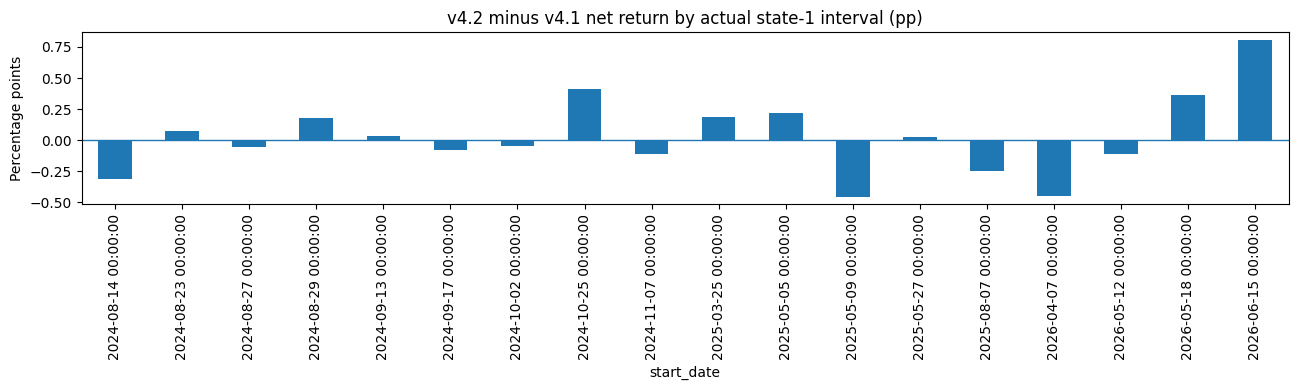

In [3]:
episodes = pd.read_csv(DIAGNOSTICS / 'state_1_lifecycle_episodes.csv', parse_dates=['start_date', 'end_date'])
lifecycle = pd.read_csv(DIAGNOSTICS / 'state_1_lifecycle_summary.csv')
display(episodes)
display(lifecycle)
if not episodes.empty:
    ax = episodes.set_index('start_date')['net_return_delta'].mul(100).plot(
        kind='bar', figsize=(13, 4), title='v4.2 minus v4.1 net return by actual state-1 interval (pp)'
    )
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Percentage points')
    plt.tight_layout()
    plt.show()

## 3. SGOV defensive-asset experiment

Exactly two structural challengers are admitted: pure SGOV defense and a 50/50 QQQI-SGOV defensive reserve. Signals, state 2, execution timing and costs remain unchanged.

In [4]:
sgov_metrics = pd.read_csv(SGOV / 'headline_metrics.csv', index_col=0)
sgov_chrono = pd.read_csv(SGOV / 'chronological_metrics.csv')
sgov_summary = json.loads((SGOV / 'experiment_summary.json').read_text(encoding='utf-8'))
display(sgov_metrics)
display(sgov_chrono)
display(pd.DataFrame(sgov_summary['diagnostics']['tail_risk']).T)

,observations,start_date,end_date,total_return,cagr,annual_volatility,sharpe,sortino,max_drawdown,calmar,switch_count,turnover_units,transaction_cost_paid,average_qqqi_weight,average_qqq_weight,average_tqqq_weight,average_sgov_weight
strategy,,,,,,,,,,,,,,,,,
current_v4_2,447,2024-10-16,2026-07-30,1.020389,0.486591,0.260685,1.652425,2.492690,-0.242245,2.008673,27,35.5,0.0355,0.624161,0.181208,0.194631,0.000000
qqqi_sgov_blended_defense,447,2024-10-16,2026-07-30,0.980257,0.469871,0.206700,1.968372,3.028467,-0.160250,2.932112,27,35.5,0.0355,0.312081,0.181208,0.194631,0.312081
sgov_pure_defense,447,2024-10-16,2026-07-30,0.913951,0.441919,0.182709,2.096039,3.283071,-0.141760,3.117378,27,35.5,0.0355,0.000000,0.181208,0.194631,0.624161


,strategy,segment,observations,start_date,end_date,total_return,cagr,annual_volatility,sharpe,sortino,max_drawdown,calmar
0,current_v4_2,early,268,2024-10-16,2025-11-10,0.404439,0.376248,0.274406,1.301740,1.923240,-0.242245,1.553169
1,current_v4_2,late,179,2025-11-11,2026-07-30,0.438574,0.668555,0.238502,2.267863,3.572192,-0.154641,4.323267
2,sgov_pure_defense,early,268,2024-10-16,2025-11-10,0.298768,0.278656,0.187497,1.406006,2.028578,-0.088809,3.137701
3,sgov_pure_defense,late,179,2025-11-11,2026-07-30,0.473666,0.726140,0.174691,3.215074,6.023525,-0.141760,5.122323
4,qqqi_sgov_blended_defense,early,268,2024-10-16,2025-11-10,0.357403,0.332864,0.213622,1.453098,2.117651,-0.160250,2.077155
5,qqqi_sgov_blended_defense,late,179,2025-11-11,2026-07-30,0.458857,0.701769,0.195528,2.819385,4.853351,-0.147582,4.755116


,daily_return_05_quantile,expected_shortfall_95,max_drawdown,max_drawdown_peak_date,max_drawdown_recovery_date,max_drawdown_recovery_sessions,max_drawdown_trough_date,maximum_underwater_run_sessions,observations,state_tail,strategy,ulcer_index,worst_10d_return,worst_20d_return,worst_5d_return,worst_daily_return
current_v4_2,-0.02258,-0.037644,-0.242245,2024-12-16,2025-06-03,114,2025-04-04,113,447,{'0': {'mean_daily_return': 0.0005193532677604...,current_v4_2,0.065342,-0.155747,-0.145808,-0.123072,-0.067185
qqqi_sgov_blended_defense,-0.016723,-0.029355,-0.16025,2024-12-16,2025-06-03,114,2025-04-04,113,447,{'0': {'mean_daily_return': 0.0003116084563380...,qqqi_sgov_blended_defense,0.056847,-0.09624,-0.102061,-0.113714,-0.067185
sgov_pure_defense,-0.011454,-0.026313,-0.14176,2026-06-02,None,None,2026-07-30,175,447,{'0': {'mean_daily_return': 0.0001038636449157...,sgov_pure_defense,0.055913,-0.106528,-0.110826,-0.104439,-0.067185


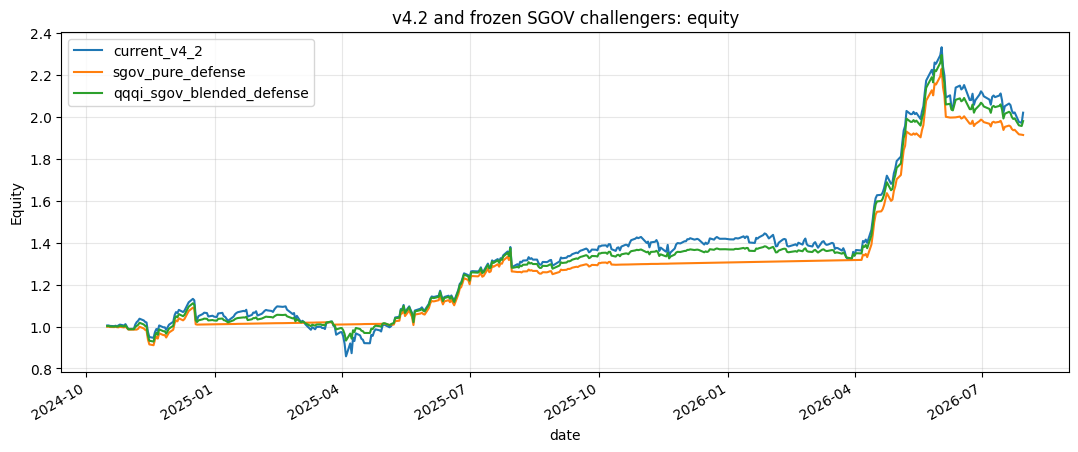

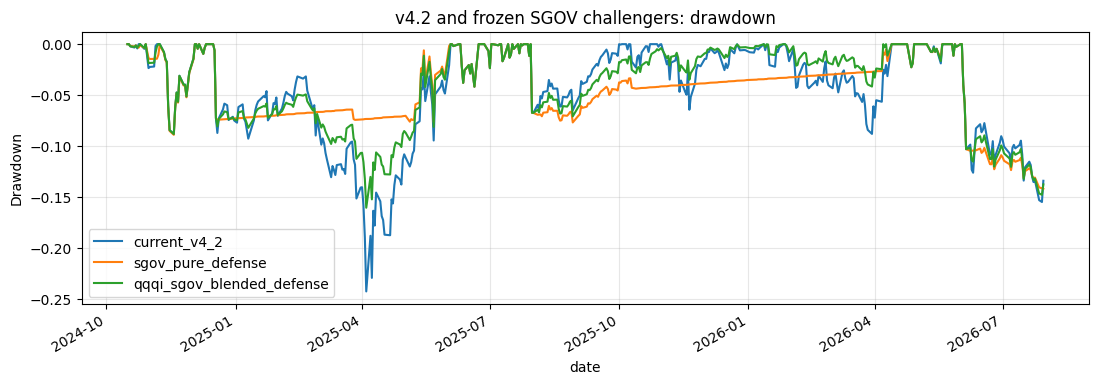

In [5]:
equity = {}
for key in ('current_v4_2', 'sgov_pure_defense', 'qqqi_sgov_blended_defense'):
    daily = pd.read_csv(SGOV / f'daily_{key}.csv', parse_dates=['date']).set_index('date')
    equity[key] = daily['equity']
equity = pd.DataFrame(equity)
ax = equity.plot(figsize=(13, 5), title='v4.2 and frozen SGOV challengers: equity')
ax.set_ylabel('Equity')
ax.grid(True, alpha=0.3)
plt.show()
drawdown = equity.div(equity.cummax()).sub(1.0)
ax = drawdown.plot(figsize=(13, 4), title='v4.2 and frozen SGOV challengers: drawdown')
ax.set_ylabel('Drawdown')
ax.grid(True, alpha=0.3)
plt.show()

## 4. Decision discipline

- v4.2 is the current research baseline.
- v4.1 remains the immutable historical signal comparator.
- The SGOV study evaluates defensive architecture, not signal quality.
- No candidate is promoted automatically from this notebook.
- Tail-risk improvement must be weighed against CAGR, Sharpe, Sortino, Calmar and chronological stability.
- Prospective evidence remains mandatory before any trade-ready designation.